# Hospital Count Mapping with Distributed GAS Agents and Multiple Request Modes

This notebook demonstrates a distributed GAS workflow that composes three geospatial agents hosted on three GAS servers:

- GAS Server 1: local GAS server, used for the `pasda_agent`
- GAS Server 2: Penn State GAS server, used for the `vector_analysis_agent`
- GAS Server 3: George Mason University GAS server, used for the `mapping_agent`

The workflow uses all three GAS request modes in one service chain. First, the PASDA Agent is called in **synchronous** mode to download Pennsylvania county boundaries and hospital locations. Next, the returned dataset URLs are passed to the Vector Analysis Agent in **asynchronous** mode, where the client submits the task, waits for completion, and retrieves the final result. Finally, the Mapping Agent is called in **streaming** mode to create a county-level choropleth map while progress events are printed as the map is generated.

This example follows the GAS service-consumer pattern. Each agent runs as an independent web service, and the client passes artifact URLs from one service to the next. The three-server deployment and three-mode execution pattern show how GAS clients can compose distributed geospatial agents while preserving a clear, reproducible workflow.


In [50]:
!pip install gas-client


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [51]:
import os
from pathlib import Path
from urllib.parse import urljoin, urlparse
import time

import requests
from dotenv import load_dotenv
from IPython.display import HTML, Image, display

project_root = Path.cwd()
if project_root.name == "examples_for_using_gas_services":
    project_root = project_root.parent

from gas_client import GasClient


## User Settings

Start the GAS servers first. The notebook reads `OPENAI_API_KEY` from the repository `.env` file and lets you override server URLs with environment variables.

In [ ]:
load_dotenv(project_root / ".env")

gas_server1 = "http://127.0.0.1:4042" # GAS Server running locally
gas_server2 = "https://www.geospatial-agentic-services.online"  # GAS Server from Penn State University
gas_server3 = "https://gas-dt.stcenter.net"# GAS Server from George Mason University

openai_api_key = os.getenv("OPENAI_API_KEY")
if not openai_api_key:
    raise RuntimeError("Set OPENAI_API_KEY in the repo .env file before running this notebook.")

poll_timeout = 2400


## Create Client and Agent Handles

In [65]:
gas1 = GasClient(
    gas_server1,
    default_credentials={"OPENAI_API_KEY": openai_api_key},
)

gas2 = GasClient(
    gas_server2,
    default_credentials={"OPENAI_API_KEY": openai_api_key},
)
gas3 = GasClient(
    gas_server3,
    default_credentials={"OPENAI_API_KEY": openai_api_key},
)


pasda_agent = gas1.agent("pasda_agent")
vector_agent = gas2.agent("vector_analysis_agent")
mapping_agent = gas3.agent("mapping_agent")


## 1. PASDA Agent: Download Pennsylvania County Boundaries (Synchronous Mode)

In synchronous mode, `ExecuteTask` returns the final task result directly after the server finishes the work.


In [53]:
county_boundaries_task = pasda_agent.execute_task(
    instructions="Download Pennsylvania counties.",
    mode="sync",
    artifact_delivery="URL",
    timeout=poll_timeout,
)

In [ ]:
gas1.print_task_summary(county_boundaries_task)

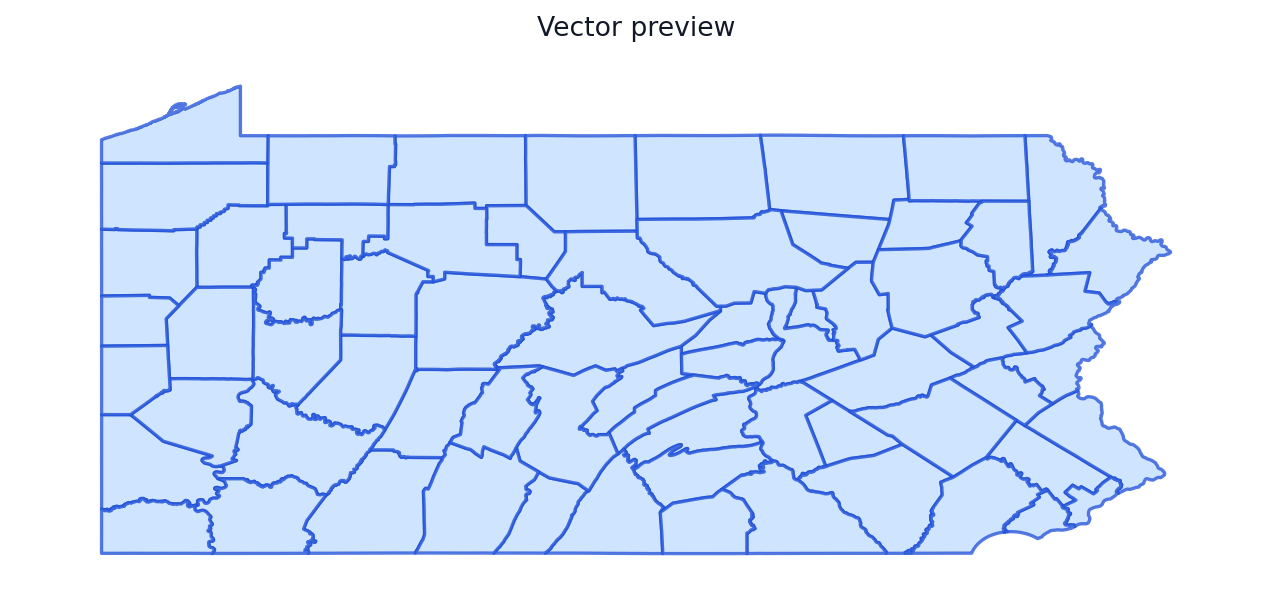

OBJECTID,COUNTY_NAM,FIPS_COUNT,DISTRICT_N,Shape_Length,Shape_Area,MSLINK,COUNTY_NUM,COUNTY_ARE,COUNTY_PER,NUMERIC_LA,COUNTY_N_1,AREA_SQ_MI,SOUND,SPREAD_SHE,IMAGE_NAME,NOTE_FILE,VIDEO,PA_CTY_COD,MAINT_CTY_,DISTRICT_O,GIS_UPDATE,GIS_GEOMET,GPID,Shape_Leng,AREA,LEN
1,MONTGOMERY,091,06,258604.89006528558,2166140724.498335,46,46,0,0,5,46,487.42705,,,poll.bmp,,,46,4,6-4,nan,nan,2079,258604.890065,0,0
2,BRADFORD,015,03,298321.64863208984,5413085970.626515,8,08,0,0,2,8,1161.337905,,,poll.bmp,,,08,9,3-9,nan,nan,2080,298321.648632,0,0
3,BUCKS,017,06,267969.25970330916,2774726527.114993,9,09,0,0,5,9,622.083587,,,poll.bmp,,,09,1,6-1,nan,nan,2081,267969.259703,0,0
4,TIOGA,117,03,291163.81794618367,5299046125.593552,58,58,0,0,2,58,1137.247962,,,poll.bmp,,,59,7,3-7,nan,nan,2082,291163.817946,0,0
5,UNION,119,03,196854.55433473396,1445163434.4653227,59,59,0,0,2,59,319.189297,,,poll.bmp,,,60,8,3-8,nan,nan,2083,196854.554335,0,0


In [55]:
gas1.display_artifacts(county_boundaries_task)

In [ ]:
county_boundaries_url = gas1.get_artifact_urls(county_boundaries_task)[0]

## 2. PASDA Agent: Download Pennsylvania Hospital Locations (Synchronous Mode)

This second PASDA request also uses synchronous mode so the notebook receives the completed hospital point dataset directly.


In [ ]:
hospital_locations_task = pasda_agent.execute_task(
    instructions="Download Pennsylvania hospital locations as a point dataset. Include hospital name, address, county, and any available identifiers.",
    mode="sync",
    artifact_delivery="URL",
    timeout=poll_timeout,
)

gas1.print_task_summary(hospital_locations_task)
hospital_locations_url = gas1.get_artifact_urls(hospital_locations_task)[0]
hospital_locations_url


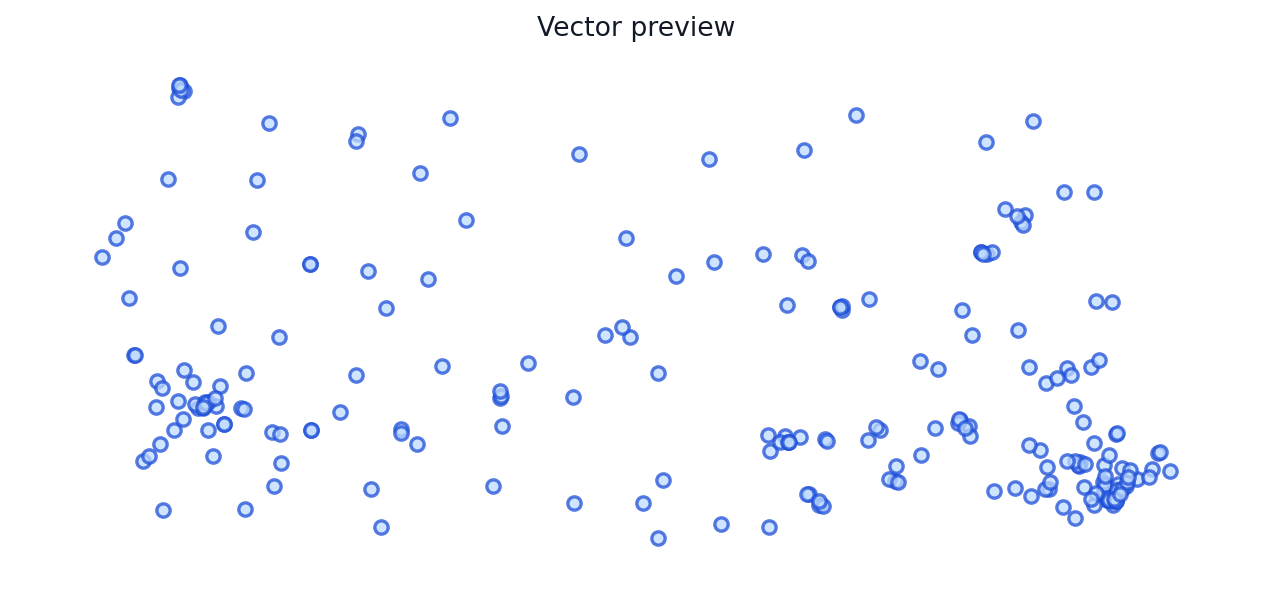

LONGITUDE,LATITUDE,STREET,COUNTY,ZIP_CODE,OBJECTID,ID_NUMBER,WEBSITE,CERTAINTY,NAME,CITY,TELEPHONE,EXEC_NAME,EXEC_TITLE
-80.190773,40.24585,100 Medical Boulevard,Washington,15317,1,29530100,http://www.ahn.org,00,Canonsburg Hospital,Canonsburg,724-745-6100,Chong Park,nan
-79.093108,41.156519,100 Hospital Road,Jefferson,15825,2,28050101,http://www.phhealthcare.org,00,Penn Highlands Brookville,Brookville,814-849-2312,Julianne Peer,nan
-75.6709132994892,40.8447934207261,500 St. Luke's Drive,Carbon,18235,3,26080101,https://www.slhn.org,00,St. Luke's Hospital Carbon Campus,Lehighton,484-464-9000,John Nespoli,nan
-75.9729985147432,40.3728420531201,201 Wellness Way,Berks,19605,4,24940101,https://www.towerbehavioralhealth.com,00,Tower Behavioral Health,Reading,484-659-2330,Jenna Pacini,nan
-76.0920015693517,40.6415399627806,100 Paramount Blvd,Schuylkill,17961,5,24870101,https://www.slhn.org,00,Geisinger St. Luke's,Orwigsburg,272-639-4990,Gabe Kamarousky,nan


In [58]:
gas1.display_artifacts(hospital_locations_task)

## 3. Vector Analysis Agent: Count Hospitals in Each County (Asynchronous Task Mode)

The Vector Analysis Agent receives the county polygon dataset and hospital point dataset returned by the PASDA Agent. It performs a point-in-polygon spatial join and returns a county polygon dataset with a hospital count field.

This step uses asynchronous task mode. The first request returns a `task_id`; the notebook then calls `GetTaskStatus` every two seconds and finally calls `GetTaskResult` when the task reaches a terminal status.


In [59]:
hospital_count_task = vector_agent.execute_task(
    "Count the number of hospital points in each Pennsylvania county.",
    mode="async",
    input_datasets=[county_boundaries_url, hospital_locations_url],
    artifact_delivery="URL",
    timeout=poll_timeout,
)

hospital_count_task_id = gas2.get_task_id(hospital_count_task)
print(f"Submitted vector analysis task: {hospital_count_task_id}")



Submitted vector analysis task: 2e82bd00-7685-4509-9980-59f0242c9ef1


In [ ]:
hospital_count_task = vector_agent.wait_for_task(
    hospital_count_task_id,
    poll_interval=2
)

gas2.print_task_summary(hospital_count_task)

if gas2.get_task_status_value(hospital_count_task) != "successful":
    raise RuntimeError("Vector analysis task did not finish successfully.")

hospital_count_url = gas2.get_artifact_urls(hospital_count_task)[0]
hospital_count_url

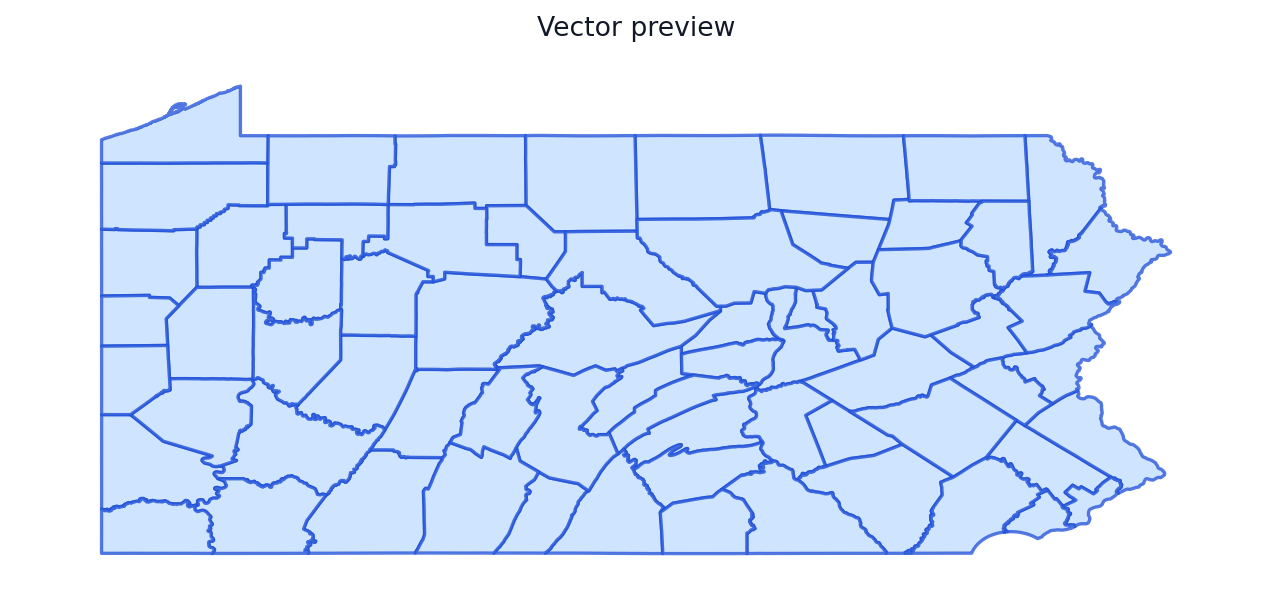

OBJECTID,COUNTY_NAM,FIPS_COUNT,DISTRICT_N,Shape_Length,Shape_Area,MSLINK,COUNTY_NUM,COUNTY_ARE,COUNTY_PER,NUMERIC_LA,COUNTY_N_1,AREA_SQ_MI,SOUND,SPREAD_SHE,IMAGE_NAME,NOTE_FILE,VIDEO,PA_CTY_COD,MAINT_CTY_,DISTRICT_O,GIS_UPDATE,GIS_GEOMET,GPID,Shape_Leng,AREA,LEN,hospital_count
1,MONTGOMERY,091,06,258604.89006528558,2166140724.498335,46,46,0,0,5,46,487.42705,,,poll.bmp,,,46,4,6-4,nan,nan,2079,258604.890065,0,0,15
2,BRADFORD,015,03,298321.64863208984,5413085970.626515,8,08,0,0,2,8,1161.337905,,,poll.bmp,,,08,9,3-9,nan,nan,2080,298321.648632,0,0,2
3,BUCKS,017,06,267969.25970330916,2774726527.114993,9,09,0,0,5,9,622.083587,,,poll.bmp,,,09,1,6-1,nan,nan,2081,267969.259703,0,0,8
4,TIOGA,117,03,291163.81794618367,5299046125.593552,58,58,0,0,2,58,1137.247962,,,poll.bmp,,,59,7,3-7,nan,nan,2082,291163.817946,0,0,1
5,UNION,119,03,196854.55433473396,1445163434.4653227,59,59,0,0,2,59,319.189297,,,poll.bmp,,,60,8,3-8,nan,nan,2083,196854.554335,0,0,1


In [61]:
gas2.display_artifacts(hospital_count_task)

## 4. Mapping Agent: Create a Choropleth Map of Hospital Counts (Streaming Mode)

The Mapping Agent uses the county-level hospital count dataset to create the final choropleth map. This step uses streaming mode so progress messages are shown while the map is being generated. This corresponds to the Figure 5C-style output described in the manuscript workflow.


In [62]:
choropleth_map_task = mapping_agent.run_streaming_task(
    (
        "Create a polished county-level choropleth map of Pennsylvania showing the number of hospitals in each county. "
        "Use a reddish color scheme and apply the Lambert Conformal Conic projection. "
        "Include a clear title and legend, and remove all axes for a clean presentation."
    ),
    input_datasets=[hospital_count_url],
    artifact_delivery="URL",
    timeout=poll_timeout,
)


[19:04:51] stream_connected: Streaming connection established.
[19:04:51] Mapping Agent: I received your request.
[19:04:51] Mapping Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 1 dataset reference(s).
[19:04:51] Mapping Agent: I found the required credentials and can start the model-backed workflow.
[19:04:52] task_accepted: Task accepted. Starting streaming execution.
[19:04:52] Mapping Agent: Next I will start the workflow with the prepared inputs.
[19:04:52] Mapping Agent: I will inspect the requested visualization and the 1 dataset reference(s), then choose whether a map or chart is the best way to answer it.
[19:04:52] Mapping Agent: I am drafting visualization code now. This is attempt 1; I will run the code and check whether it creates the requested output correctly.
[19:05:02] Mapping Agent: Still working on map_design: I am drafting visualization code now. This is attempt 1; I will run the code and check wheth

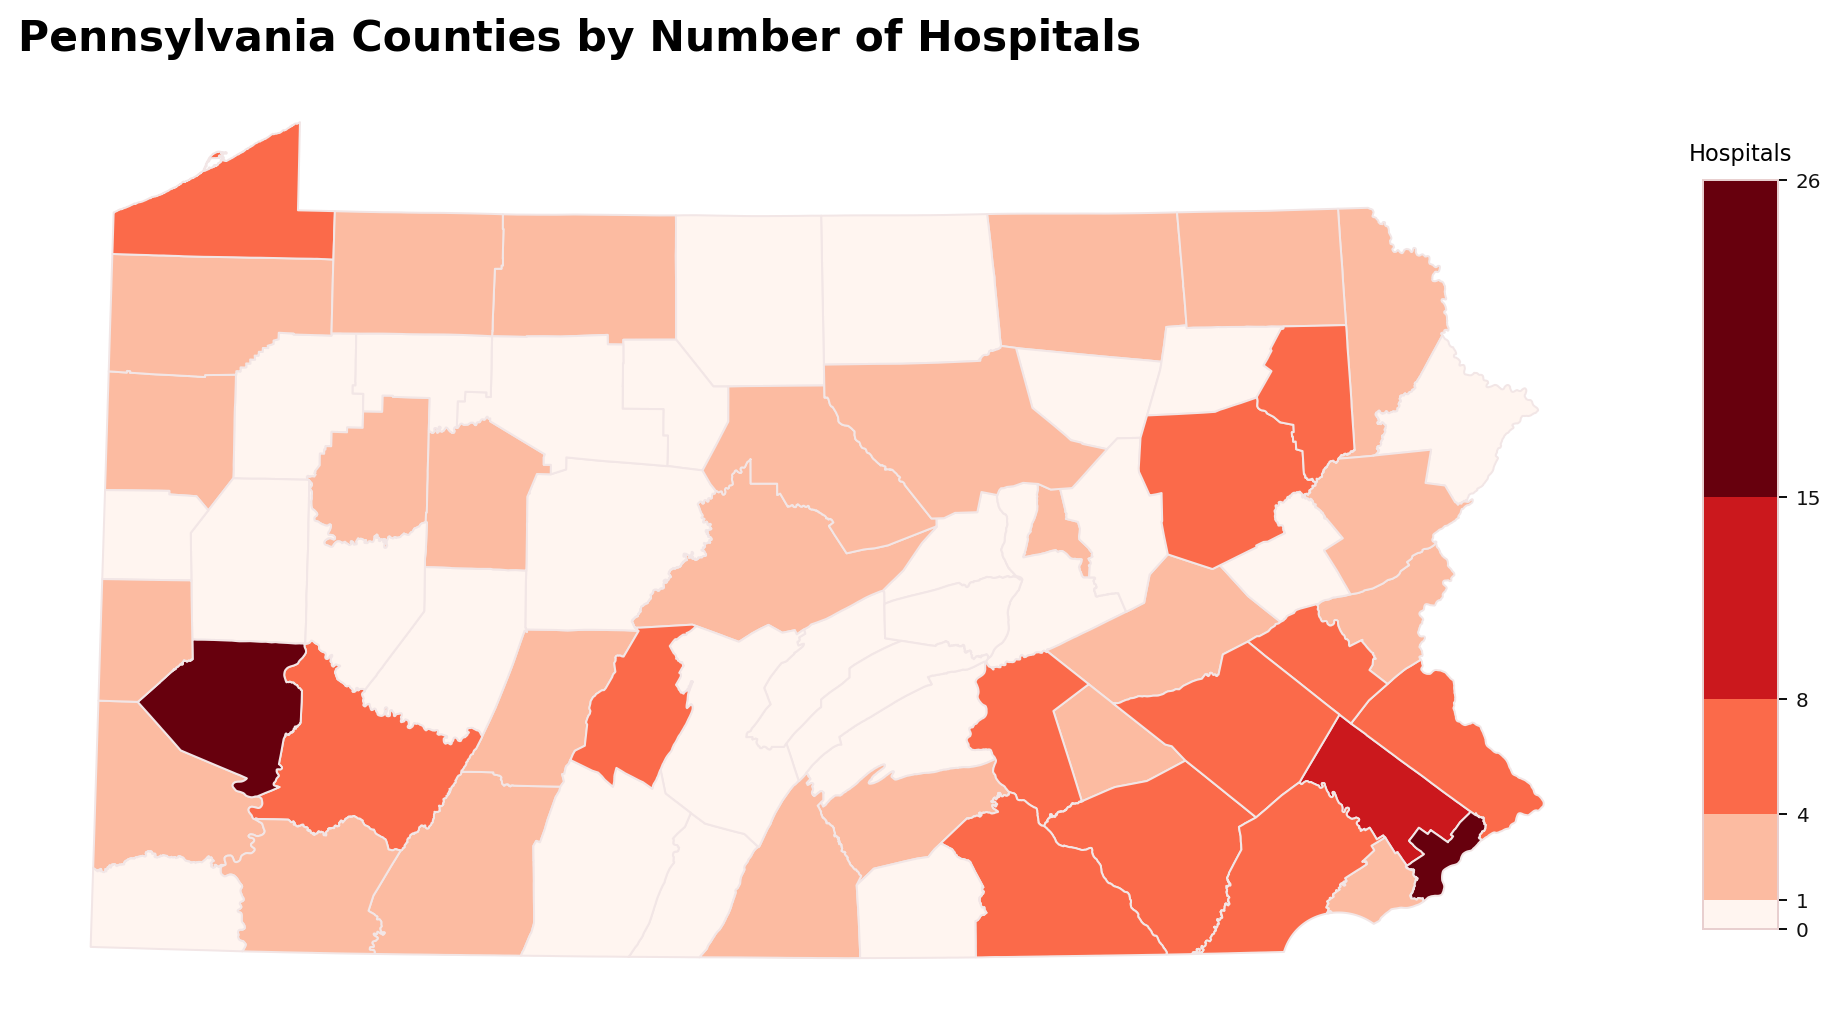

In [63]:
gas3.display_artifacts(choropleth_map_task)